# Time Series with Deep Learning

* LSTM : Long Short Time Memory 
* LSTM : Gelecek zaman serisi, metin serisini tahmin ediyor.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.layers import Dense, LSTM # LSTM

I0000 00:00:1781107441.423216   36072 pjrt_api.cc:97] PJRT_Api is set for device type gpu
I0000 00:00:1781107441.427707   36072 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#pip install nvidia-cuda-runtime-cu12 nvidia-cudnn-cu12

In [17]:
import tensorflow as tf
print("Ekran Kartı Aktif mi?:", tf.test.is_built_with_cuda())
print("Kullanılabilir Aygıtlar:", tf.config.list_physical_devices('GPU'))

Ekran Kartı Aktif mi?: True
Kullanılabilir Aygıtlar: []


In [18]:
import os
import sys

# Sanal ortamınızın (venv) yolunu otomatik bulup kütüphaneleri ekleyelim
venv_path = sys.prefix
os.environ['LD_LIBRARY_PATH'] = f"{venv_path}/lib/{sys.version_info.major}.{sys.version_info.minor}/site-packages/nvidia/cudnn/lib/:{venv_path}/lib/{sys.version_info.major}.{sys.version_info.minor}/site-packages/nvidia/cuda_runtime/lib/"

# Şimdi TensorFlow'u import edip tekrar deneyelim
import tensorflow as tf
print("Kullanılabilir Aygıtlar:", tf.config.list_physical_devices('GPU'))

Kullanılabilir Aygıtlar: []


In [3]:
import tensorflow as tf
print("Kullanılabilir GPU'lar:", tf.config.list_physical_devices('GPU'))

Kullanılabilir GPU'lar: []


W0000 00:00:1781107446.256139   36072 dlopen_checker.cc:38] Could not load dynamic library 'libcufft.so.11'; dlerror: libcufft.so.11: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/zaid/Desktop/Yapay-Zeka-Kursu/venv/lib/python3.14/site-packages/cv2/../../lib64:
W0000 00:00:1781107446.256189   36072 dlopen_checker.cc:38] Could not load dynamic library 'libcusolver.so.11'; dlerror: libcusolver.so.11: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/zaid/Desktop/Yapay-Zeka-Kursu/venv/lib/python3.14/site-packages/cv2/../../lib64:
W0000 00:00:1781107446.256197   36072 dlopen_checker.cc:38] Could not load dynamic library 'libcusparse.so.12'; dlerror: libcusparse.so.12: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/zaid/Desktop/Yapay-Zeka-Kursu/venv/lib/python3.14/site-packages/cv2/../../lib64:
W0000 00:00:1781107446.256207   36072 gpu_device.cc:2364] Cannot dlopen some GPU libraries. Pleas

In [19]:
%pip uninstall nvidia-cuda-runtime-cu12 nvidia-cudnn-cu12 tensorflow
%pip install tensorflow[and-cuda]

Found existing installation: nvidia-cuda-runtime-cu12 12.9.79
Uninstalling nvidia-cuda-runtime-cu12-12.9.79:
  Would remove:
    /home/zaid/Desktop/Yapay-Zeka-Kursu/venv/lib/python3.14/site-packages/nvidia/cuda_runtime/include/builtin_types.h
    /home/zaid/Desktop/Yapay-Zeka-Kursu/venv/lib/python3.14/site-packages/nvidia/cuda_runtime/include/channel_descriptor.h
    /home/zaid/Desktop/Yapay-Zeka-Kursu/venv/lib/python3.14/site-packages/nvidia/cuda_runtime/include/common_functions.h
    /home/zaid/Desktop/Yapay-Zeka-Kursu/venv/lib/python3.14/site-packages/nvidia/cuda_runtime/include/cooperative_groups.h
    /home/zaid/Desktop/Yapay-Zeka-Kursu/venv/lib/python3.14/site-packages/nvidia/cuda_runtime/include/cooperative_groups/details/async.h
    /home/zaid/Desktop/Yapay-Zeka-Kursu/venv/lib/python3.14/site-packages/nvidia/cuda_runtime/include/cooperative_groups/details/coalesced_reduce.h
    /home/zaid/Desktop/Yapay-Zeka-Kursu/venv/lib/python3.14/site-packages/nvidia/cuda_runtime/include/coo

In [4]:
# 1. NVIDIA CUDA araçlarını pip üzerinden yükleyin
#pip install nvidia-cuda-runtime-idx nvidia-cudnn-cu11

# 2. Sistem yollarını (Path) Python'a tanıtın (Geçici olarak terminale yapıştırın)
#export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:$VIRTUAL_ENV/lib/


In [5]:
df = pd.read_csv("Google_Stock_Price_Train.csv")

In [6]:
df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [7]:
train_set=df.iloc[:,1:2].values

In [8]:
sc = MinMaxScaler()

In [9]:
train_set = sc.fit_transform(train_set)

In [10]:
x_train=train_set[0:1257]
y_train=train_set[1:1258]

In [11]:
model=Sequential()
model.add(LSTM(units=4,activation='sigmoid', input_shape=(None,1)))
model.add(Dense(units=1))

/home/zaid/Desktop/Yapay-Zeka-Kursu/venv/lib/python3.14/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [13]:
model.fit(x_train,y_train, batch_size=32, epochs=200)

Epoch 1/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.7875
Epoch 2/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6313
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5043
Epoch 4/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4027
Epoch 5/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3211
Epoch 6/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2568
Epoch 7/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2063
Epoch 8/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1675
Epoch 9/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1379
Epoch 10/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1161
Epoch 11/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1003
Epoch 12/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0889
Epoch 13/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0813
Epoch 14/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0760
Epoch 15/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0725
Epoc

In [14]:
test = pd.read_csv("Google_Stock_Price_Test.csv")

In [15]:
test = test.iloc[:,1:2].values
test_set = sc.fit_transform(test)
tahmin = model.predict(test_set)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step


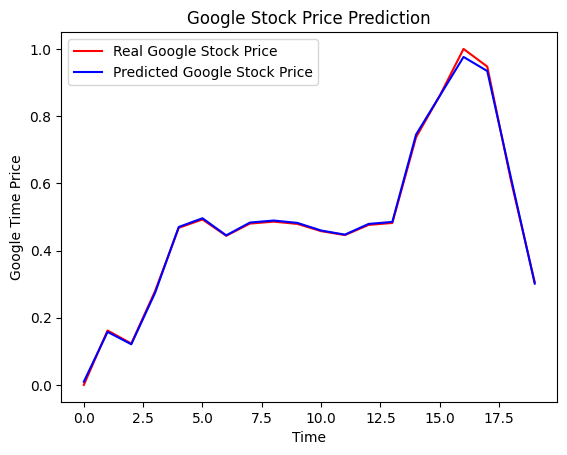

In [16]:
plt.plot(test_set, color = 'red', label = 'Real Google Stock Price')
plt.plot(tahmin, color = 'blue', label = 'Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Time Price')
plt.legend()
plt.show()